In [1]:
import pandas as pd
import glob
import os
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Define folder path ===
folder_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata"

# === 2. Find all climate CSV files ===
all_files = glob.glob(os.path.join(folder_path, "climate-daily*.csv"))

if not all_files:
    raise FileNotFoundError(f"No files found matching pattern in: {folder_path}")

print(f"Found {len(all_files)} CSV files to merge.")

# === 3. Read and merge all CSVs ===
df_list = []
for f in all_files:
    print(f"Reading: {os.path.basename(f)}")
    df = pd.read_csv(f, low_memory=False)  # prevents DtypeWarning
    df_list.append(df)

merged_df = pd.concat(df_list, ignore_index=True)
print(f"Merged {len(df_list)} files. Shape: {merged_df.shape}")

# === 4. Keep only required columns ===
keep_cols = [
    "STATION_NAME",
    "LOCAL_DATE",
    "LOCAL_YEAR",
    "LOCAL_MONTH",
    "LOCAL_DAY",
    "TOTAL_PRECIPITATION"
]
merged_df = merged_df[keep_cols]

# === 5. Ensure LOCAL_YEAR is numeric and filter 1995–2024 ===
merged_df["LOCAL_YEAR"] = pd.to_numeric(merged_df["LOCAL_YEAR"], errors="coerce")
merged_df = merged_df[
    (merged_df["LOCAL_YEAR"] >= 1995) & (merged_df["LOCAL_YEAR"] <= 2024)
]

# === 6. Map STATION_NAME → RM ===
station_to_rm = {
    "ASSINIBOIA AIRPORT": 72,
    "BEECHY": 226,
    "BROADVIEW": 154,
    "BUTTE ST PIERRE": 501,
    "COLLINS BAY CAMECO": 344,
    "CORONACH SPC": 3,
    "CYPRESS HILLS PARK": 111,
    "DUVAL": 197,
    "EASTEND CYPRESS (AUT)": 49,
    "ELBOW CS": 254,
    "INDIAN HEAD CDA": 156,
    "KELLIHER": 247,
    "KIPLING": 124,
    "LEADER AIRPORT": 231,
    "LEROY": 339,
    "LIPTON 2": 217,
    "LUCKY LAKE": 225,
    "MANKOTA": 45,
    "MAPLE CREEK": 113,
    "OUTLOOK PFRA": 284,
    "PARKERVIEW": 191,
    "QU'APPELLE 1": 187,
    "ROCK POINT": 158,
    "ROCKGLEN (AUT)": 76,
    "ROSETOWN EAST": 321,
    "SCOTT CDA": 471,
    "SONNINGDALE": 376,
    "SPIRITWOOD WEST": 496,
    "SWIFT CURRENT CDA": 137,
    "VAL MARIE SOUTHEAST": 17,
    "WASKESIU LAKE": 488,
    "WATROUS EAST": 342,
    "WEYBURN": 67,
    "WYNYARD (AUT)": 338
}

merged_df["RMs"] = merged_df["STATION_NAME"].map(station_to_rm)

# === 7. Sort data by LOCAL_YEAR, LOCAL_MONTH, LOCAL_DAY, and RMs ===
merged_df = merged_df.sort_values(
    by=["LOCAL_YEAR", "LOCAL_MONTH", "LOCAL_DAY", "RMs"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("Data sorted by year, month, day, and RM.")

# === 8. Save final output ===
output_file = os.path.join(folder_path, "climate-daily-merged-1995-2024-with-RMs.csv")
merged_df.to_csv(output_file, index=False)

# === 9. Done ===
print(f"\n Final sorted dataset saved to:\n{output_file}")
print(f"Shape: {merged_df.shape[0]} rows × {merged_df.shape[1]} columns\n")
print(merged_df.head(10))

Found 64 CSV files to merge.
Reading: climate-daily (31).csv
Reading: climate-daily (27).csv
Reading: climate-daily (2).csv
Reading: climate-daily (50).csv
Reading: climate-daily (11).csv
Reading: climate-daily (46).csv
Reading: climate-daily (47).csv
Reading: climate-daily (10).csv
Reading: climate-daily (51).csv
Reading: climate-daily (3).csv
Reading: climate-daily (26).csv
Reading: climate-daily (30).csv
Reading: climate-daily (4).csv
Reading: climate-daily (56).csv
Reading: climate-daily (17).csv
Reading: climate-daily (40).csv
Reading: climate-daily.csv
Reading: climate-daily (37).csv
Reading: climate-daily (60).csv
Reading: climate-daily (21).csv
Reading: climate-daily (8).csv
Reading: climate-daily (9).csv
Reading: climate-daily (20).csv
Reading: climate-daily (61).csv
Reading: climate-daily (36).csv
Reading: climate-daily (41).csv
Reading: climate-daily (16).csv
Reading: climate-daily (57).csv
Reading: climate-daily (5).csv
Reading: climate-daily (42).csv
Reading: climate-daily

In [2]:
# Filter rows where TOTAL_PRECIPITATION is missing
missing_precip = merged_df[merged_df['TOTAL_PRECIPITATION'].isna()]

# Get unique RMs and Station Names for those rows
unique_RMs = sorted(missing_precip['RMs'].dropna().unique())
unique_stations = sorted(missing_precip['STATION_NAME'].dropna().unique())

print("Unique RMs with missing TOTAL_PRECIPITATION:")
print(unique_RMs)

print("\nUnique STATION_NAMEs with missing TOTAL_PRECIPITATION:")
print(unique_stations)

# Count of unique station names
print(f"\nTotal unique stations with missing TOTAL_PRECIPITATION: {len(unique_stations)}")

Unique RMs with missing TOTAL_PRECIPITATION:
[3, 17, 45, 49, 67, 72, 76, 111, 113, 124, 137, 154, 156, 158, 191, 197, 217, 225, 231, 247, 254, 284, 321, 338, 342, 344, 376, 471, 488, 496, 501]

Unique STATION_NAMEs with missing TOTAL_PRECIPITATION:
['ASSINIBOIA AIRPORT', 'BROADVIEW', 'BUTTE ST PIERRE', 'COLLINS BAY CAMECO', 'CORONACH SPC', 'CYPRESS HILLS PARK', 'DUVAL', 'EASTEND CYPRESS (AUT)', 'ELBOW CS', 'INDIAN HEAD CDA', 'KELLIHER', 'KIPLING', 'LEADER AIRPORT', 'LIPTON 2', 'LUCKY LAKE', 'MANKOTA', 'MAPLE CREEK', 'OUTLOOK PFRA', 'PARKERVIEW', 'ROCK POINT', 'ROCKGLEN (AUT)', 'ROSETOWN EAST', 'SCOTT CDA', 'SONNINGDALE', 'SPIRITWOOD WEST', 'SWIFT CURRENT CDA', 'VAL MARIE SOUTHEAST', 'WASKESIU LAKE', 'WATROUS EAST', 'WEYBURN', 'WYNYARD (AUT)']

Total unique stations with missing TOTAL_PRECIPITATION: 31


In [3]:
# Group by RMs and check which have no missing TOTAL_PRECIPITATION
complete_RMs = (
    merged_df.groupby('RMs')['TOTAL_PRECIPITATION']
    .apply(lambda x: x.notna().all())  # True if all values are non-missing
)
# Filter to keep only RMs with complete data
RMs_with_complete_data = sorted(complete_RMs[complete_RMs].index.tolist())

print("RMs with complete TOTAL_PRECIPITATION data for the whole range:")
print(RMs_with_complete_data)

# Count of complete RMs
print(f"\nTotal RMs with complete precipitation data: {len(RMs_with_complete_data)}")

RMs with complete TOTAL_PRECIPITATION data for the whole range:
[187, 226, 339]

Total RMs with complete precipitation data: 3


In [4]:
# filter RMs with complete TOTAL_PRECIPITATION data for the whole range: 187, 226, 339
filtered_df = merged_df[merged_df["RMs"].isin([187, 226, 339])]
print(filtered_df.head(25))
# save it to the folder for review
filtered_df_output = os.path.join(folder_path, "filtered_precipitation.csv")
filtered_df.to_csv(filtered_df_output, index=False)

     STATION_NAME           LOCAL_DATE  LOCAL_YEAR  LOCAL_MONTH  LOCAL_DAY  \
14   QU'APPELLE 1  1995-01-01 00:00:00        1995            1          1   
19         BEECHY  1995-01-01 00:00:00        1995            1          1   
26          LEROY  1995-01-01 00:00:00        1995            1          1   
48   QU'APPELLE 1  1995-01-02 00:00:00        1995            1          2   
53         BEECHY  1995-01-02 00:00:00        1995            1          2   
60          LEROY  1995-01-02 00:00:00        1995            1          2   
82   QU'APPELLE 1  1995-01-03 00:00:00        1995            1          3   
87         BEECHY  1995-01-03 00:00:00        1995            1          3   
94          LEROY  1995-01-03 00:00:00        1995            1          3   
116  QU'APPELLE 1  1995-01-04 00:00:00        1995            1          4   
121        BEECHY  1995-01-04 00:00:00        1995            1          4   
128         LEROY  1995-01-04 00:00:00        1995            1 

In [5]:
# Drop unneeded columns
precip = filtered_df.drop(columns=['STATION_NAME', 'LOCAL_DATE'])

# --- Create full set of (year, RM, month, day) combinations
years = precip['LOCAL_YEAR'].unique()
rms = precip['RMs'].unique()
months = range(1, 13)
days = range(1, 32)

full_index = pd.MultiIndex.from_product(
    [years, rms, months, days],
    names=['LOCAL_YEAR', 'RMs', 'LOCAL_MONTH', 'LOCAL_DAY']
)

# --- Reindex to ensure every combo exists, fill missing with 0
precip_full = (
    precip.set_index(['LOCAL_YEAR', 'RMs', 'LOCAL_MONTH', 'LOCAL_DAY'])
           .reindex(full_index, fill_value=0)
           .reset_index()
)

# --- Pivot months into columns
precip_wide = precip_full.pivot_table(
    index=['LOCAL_YEAR', 'RMs', 'LOCAL_DAY'],
    columns='LOCAL_MONTH',
    values='TOTAL_PRECIPITATION',
    aggfunc='sum',
    fill_value=0
).reset_index()

# --- Clean up column names
precip_wide.columns.name = None
precip_wide = precip_wide.rename(columns={
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})
precip_wide.tail(10)

,LOCAL_YEAR,RMs,LOCAL_DAY,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2780,2024,339,22,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.2,0.0
2781,2024,339,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.6,0.6,0.0,21.2,0.0
2782,2024,339,24,0.0,0.0,0.0,0.0,0.0,0.6,0.0,0.0,0.0,0.0,6.0,0.0
2783,2024,339,25,0.0,11.0,0.0,0.0,0.0,6.2,0.0,0.0,0.0,0.0,0.0,0.0
2784,2024,339,26,0.0,2.6,0.0,0.0,0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2785,2024,339,27,0.0,0.0,0.0,0.0,0.0,21.4,0.0,0.0,0.0,0.0,0.8,2.8
2786,2024,339,28,0.0,0.0,4.8,0.0,0.0,1.4,0.0,3.4,0.0,0.0,0.0,0.0
2787,2024,339,29,0.0,0.0,1.4,0.0,2.2,0.0,0.0,0.6,0.4,0.0,0.0,0.0
2788,2024,339,30,0.0,0.0,0.0,0.0,2.8,4.6,0.0,0.0,3.4,0.0,5.6,0.0
2789,2024,339,31,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
# Keep all months Jan–Dec
precip_wide = precip_wide[['LOCAL_YEAR', 'RMs', 'LOCAL_DAY',
                           'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                           'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']]

precip_wide.head(5)


,LOCAL_YEAR,RMs,LOCAL_DAY,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1995,187,1,0.0,0.0,0.0,0.6,0.0,0.0,2.5,0.0,0.0,21.2,1.8,7.5
1,1995,187,2,0.0,0.0,0.6,0.5,0.0,0.0,0.0,1.1,0.0,0.4,0.0,0.0
2,1995,187,3,0.0,8.0,0.0,0.0,0.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1995,187,4,0.0,0.0,2.6,1.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1995,187,5,0.0,0.0,0.3,0.0,0.0,53.8,0.8,0.0,34.2,0.0,0.0,0.0


In [7]:
import numpy as np

# -----------------------------------------------------------
# 1. Melt Jan–Dec into long format
# -----------------------------------------------------------

month_cols = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

precip_long = precip_wide.melt(
    id_vars=['LOCAL_YEAR', 'RMs', 'LOCAL_DAY'],
    value_vars=month_cols,
    var_name='Month',
    value_name='Rain'
)

# -----------------------------------------------------------
# 2. Month day lengths
# (non-leap-year basis; change if needed)
# -----------------------------------------------------------

month_days = {
    'Jan': 31, 'Feb': 28, 'Mar': 31, 'Apr': 30,
    'May': 31, 'Jun': 30, 'Jul': 31, 'Aug': 31,
    'Sep': 30, 'Oct': 31, 'Nov': 30, 'Dec': 31
}

# Order for cumulative offsets
month_order = list(month_days.keys())

# -----------------------------------------------------------
# 3. Compute cumulative offsets
# -----------------------------------------------------------

month_offsets = {}
cumulative = 0
for m in month_order:
    month_offsets[m] = cumulative
    cumulative += month_days[m]

# -----------------------------------------------------------
# 4. Compute overall day index (1–365)
# -----------------------------------------------------------

precip_long['Day_Index'] = precip_long.apply(
    lambda x: month_offsets[x['Month']] + x['LOCAL_DAY']
    if x['LOCAL_DAY'] <= month_days[x['Month']] else np.nan,
    axis=1
)

# remove invalid day-month combos (e.g., Feb 30)
precip_long = precip_long.dropna(subset=['Day_Index'])

# -----------------------------------------------------------
# 5. Assign 10-day subperiods
# -----------------------------------------------------------

precip_long['Subperiod'] = np.ceil(precip_long['Day_Index'] / 10).astype(int)

# Total subperiods per year = ceil(365/10) = 37
# Adjusts automatically.

# -----------------------------------------------------------
# 6. Aggregate rainfall per subperiod
# -----------------------------------------------------------

subperiod_sum = (
    precip_long
    .groupby(['LOCAL_YEAR', 'RMs', 'Subperiod'], as_index=False)['Rain']
    .sum()
)

# -----------------------------------------------------------
# 7. Pivot to wide format: Period_1 ... Period_37
# -----------------------------------------------------------

subperiod_wide = subperiod_sum.pivot_table(
    index=['LOCAL_YEAR', 'RMs'],
    columns='Subperiod',
    values='Rain',
    fill_value=0
).reset_index()

# rename columns
subperiod_wide.columns.name = None
subperiod_wide = subperiod_wide.rename(
    columns={i: f'Period_{i}' for i in range(1, 38)}  # Period_1–Period_37
)

# -----------------------------------------------------------
# 8. Save
# -----------------------------------------------------------

subperiod_wide.to_csv(
    '/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/subperiod_rainfall_full_year.csv',
    index=False
)

print(subperiod_wide.shape)
print(subperiod_wide.head())


(90, 39)
   LOCAL_YEAR  RMs  Period_1  Period_2  Period_3  Period_4  Period_5  \
0        1995  187       4.8      15.8       0.0       8.2       0.2   
1        1995  226       2.6      11.0       0.0       0.4       2.5   
2        1995  339       4.0       4.8       2.8       7.8       1.0   
3        1996  187       0.2       7.4       0.6      14.0       7.2   
4        1996  226       4.0      12.0       2.6       3.0       0.0   

   Period_6  Period_7  Period_8  ...  Period_28  Period_29  Period_30  \
0       2.8       3.5      33.2  ...       22.7       31.0       15.8   
1       0.2       1.4       0.0  ...        6.6        9.2        3.0   
2      12.8       1.2      29.4  ...       11.4       28.2       17.2   
3       0.0       0.0       3.0  ...       19.8        0.0        4.0   
4       3.0       0.0       2.0  ...       14.4        6.3        4.2   

   Period_31  Period_32  Period_33  Period_34  Period_35  Period_36  Period_37  
0        6.5       13.9       23.4    

In [8]:
# --- Step 1: Load the dataset ---
file1_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/RM-Canola-1992_2024.csv"
df1 = pd.read_csv(file1_path)

# --- Step 2: Keep only needed columns ---
df1 = df1[['Year', 'RM', 'Canola']]

# --- Step 3: Filter by RM list and Year range ---
rm_list = [187, 226, 339]

yield_filtered = df1[
    (df1['RM'].isin(rm_list)) &
    (df1['Year'].between(1995, 2024))
].reset_index(drop=True)

# --- Step 4: Define output path and save ---
output_folder = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata"
output_file = os.path.join(output_folder, "RM_canola_yield_1995_2024.csv")

yield_filtered.to_csv(output_file, index=False)

print(f" Filtered Canola dataset saved successfully to:\n{output_file}")
print(f"Shape: {yield_filtered.shape[0]} rows × {yield_filtered.shape[1]} columns")
print(yield_filtered.head())

 Filtered Canola dataset saved successfully to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/RM_canola_yield_1995_2024.csv
Shape: 90 rows × 3 columns
   Year   RM  Canola
0  1995  187    15.0
1  1996  187    20.5
2  1997  187    19.0
3  1998  187    23.7
4  1999  187    22.7


In [9]:
import os

# ---- path for output ----
out_dir = '/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results'
os.makedirs(out_dir, exist_ok=True)

# ---- Constants ----
price_per_kg = 13.73     # CAD per kg

# ---- Load ----
sub = subperiod_wide          # from previous step (Period_1–Period_37)
yld = yield_filtered          # yield file

# ---- Quick checks & normalize column names ----
print("subperiod shape:", sub.shape)
print(sub.head())

print("\nyield shape:", yld.shape)
print(yld.head())

# Standardize column names
sub.columns = [c.strip() for c in sub.columns]
yld.columns = [c.strip() for c in yld.columns]

# ---- Rename yield columns to match merge keys ----
yld = yld.rename(columns={
    'Year': 'LOCAL_YEAR',
    'RM': 'RMs',
    'Canola': 'Yield_raw'
})

# ---- Convert types ----
sub['LOCAL_YEAR'] = sub['LOCAL_YEAR'].astype(int)
sub['RMs'] = sub['RMs'].astype(int)
yld['LOCAL_YEAR'] = yld['LOCAL_YEAR'].astype(int)
yld['RMs'] = yld['RMs'].astype(int)

# ---- Use yield as-is ----
yld['Yield_kg_ha'] = yld['Yield_raw'].astype(float)

# -------------------------------------------------------------
# ✔ Automatically detect all period columns (Period_1..Period_N)
# -------------------------------------------------------------

period_cols = [c for c in sub.columns if c.startswith("Period_")]

print(f"\nDetected {len(period_cols)} subperiods:", period_cols[:5], "...")

# ---- Ensure at least SOME period columns exist ----
if len(period_cols) == 0:
    raise ValueError("No Period_* columns found in the subperiod_wide file!")

# ---- Merge yield with rainfall subperiod table ----
df = sub.merge(
    yld[['LOCAL_YEAR', 'RMs', 'Yield_kg_ha']],
    on=['LOCAL_YEAR', 'RMs'],
    how='left'
)

# ---- Report missing yields ----
missing_y = df[df['Yield_kg_ha'].isna()][['LOCAL_YEAR', 'RMs']].drop_duplicates()
if not missing_y.empty:
    print("\n⚠ Warning: missing yield for these (year, RM) rows:")
    print(missing_y.head(20))
else:
    print("\n✔ All years/RMs have yield entries merged successfully.")

# ---- Save merged file ----
merged_path = os.path.join(out_dir, 'merged_subperiods_yield_full_year.csv')
df.to_csv(merged_path, index=False)

print("\nSaved merged file to:", merged_path)

# ---- Show sample rows ----
print("\nSample of merged dataset:")
print(df[['LOCAL_YEAR', 'RMs', 'Yield_kg_ha'] + period_cols].head(3))


subperiod shape: (90, 39)
   LOCAL_YEAR  RMs  Period_1  Period_2  Period_3  Period_4  Period_5  \
0        1995  187       4.8      15.8       0.0       8.2       0.2   
1        1995  226       2.6      11.0       0.0       0.4       2.5   
2        1995  339       4.0       4.8       2.8       7.8       1.0   
3        1996  187       0.2       7.4       0.6      14.0       7.2   
4        1996  226       4.0      12.0       2.6       3.0       0.0   

   Period_6  Period_7  Period_8  ...  Period_28  Period_29  Period_30  \
0       2.8       3.5      33.2  ...       22.7       31.0       15.8   
1       0.2       1.4       0.0  ...        6.6        9.2        3.0   
2      12.8       1.2      29.4  ...       11.4       28.2       17.2   
3       0.0       0.0       3.0  ...       19.8        0.0        4.0   
4       3.0       0.0       2.0  ...       14.4        6.3        4.2   

   Period_31  Period_32  Period_33  Period_34  Period_35  Period_36  Period_37  
0        6.5       13

In [22]:
##################### SPLIT CLEAN VS MISSING ROWS ############################

# Path to merged file created in previous chunk
merged_path = os.path.join(out_dir, 'merged_subperiods_yield_clean.csv')

# Load the merged dataset
df2 = pd.read_csv(merged_path)

print("Loaded merged file:", df2.shape)

# Identify rows with missing yield
missing_rows = df2[df2['Yield_kg_ha'].isna()].copy()
clean_rows = df2[df2['Yield_kg_ha'].notna()].copy()

print(f"Rows with missing yield: {len(missing_rows)}")
print(f"Rows with complete yield: {len(clean_rows)}")

# Save missing rows
missing_out = os.path.join(out_dir, 'missing_yield_rows.csv')
missing_rows.to_csv(missing_out, index=False)
print(f"Saved missing rows to: {missing_out}")

# Save clean rows
clean_out = os.path.join(out_dir, 'clean_merged_yield_data.csv')
clean_rows.to_csv(clean_out, index=False)
print(f"Saved clean rows to: {clean_out}")

# Preview clean rows
print("\nPreview of clean rows:")
print(clean_rows.head(3))


Loaded merged file: (89, 40)
Rows with missing yield: 0
Rows with complete yield: 89
Saved missing rows to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results/missing_yield_rows.csv
Saved clean rows to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results/clean_merged_yield_data.csv

Preview of clean rows:
   LOCAL_YEAR  RMs  Period_1  Period_2  Period_3  Period_4  Period_5  \
0        1995  187       4.8      15.8       0.0       8.2       0.2   
1        1995  226       2.6      11.0       0.0       0.4       2.5   
2        1995  339       4.0       4.8       2.8       7.8       1.0   

   Period_6  Period_7  Period_8  ...  Period_29  Period_30  Period_31  \
0       2.8       3.5      33.2  ...       31.0       15.8        6.5   
1       0.2       1.4       0.0  ...        9.2        3.0       10.0   
2      12.8       1.2      29.4  ...       28.2       17.2        5.2   

   Period_32  Period_33  Period_34  Period_35  Period_36  Period

In [11]:
##################### SPLIT CLEAN VS MISSING ROWS ############################

# Path to merged file created in previous chunk
merged_path = os.path.join(out_dir, 'merged_subperiods_yield_clean.csv')

# Load it
df2 = pd.read_csv(merged_path)

# Identify missing-yield rows
missing_rows = df2[df2['Yield_kg_ha'].isna()].copy()
clean_rows = df2[df2['Yield_kg_ha'].notna()].copy()

# Save missing rows separately
missing_out = os.path.join(out_dir, 'missing_yield_rows.csv')
missing_rows.to_csv(missing_out, index=False)
print(f"Saved missing rows to: {missing_out}")

# Save clean rows separately
clean_out = os.path.join(out_dir, 'clean_merged_yield_data.csv')
clean_rows.to_csv(clean_out, index=False)
print(f"Saved clean rows to: {clean_out}")

# Preview
print("Preview of clean rows:")
print(clean_rows.head(3))


Saved missing rows to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results/missing_yield_rows.csv
Saved clean rows to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results/clean_merged_yield_data.csv
Preview of clean rows:
   LOCAL_YEAR  RMs  Period_1  Period_2  Period_3  Period_4  Period_5  \
0        1995  187       4.8      15.8       0.0       8.2       0.2   
1        1995  226       2.6      11.0       0.0       0.4       2.5   
2        1995  339       4.0       4.8       2.8       7.8       1.0   

   Period_6  Period_7  Period_8  ...  Period_29  Period_30  Period_31  \
0       2.8       3.5      33.2  ...       31.0       15.8        6.5   
1       0.2       1.4       0.0  ...        9.2        3.0       10.0   
2      12.8       1.2      29.4  ...       28.2       17.2        5.2   

   Period_32  Period_33  Period_34  Period_35  Period_36  Period_37  \
0       13.9       23.4        8.1       14.4        1.2        4.1   
1       

In [12]:
import numpy as np
from scipy.stats import pearsonr

# Use the cleaned dataset
df_clean = clean_rows.copy()

# --- Detect all Period_* columns dynamically ---
period_cols = [c for c in df_clean.columns if c.startswith("Period_")]
period_cols = sorted(period_cols, key=lambda x: int(x.split("_")[1]))  # ensure correct numeric order

print(f"Using {len(period_cols)} subperiods:", period_cols[:5], "...")

# Equal weights for all detected subperiods
equal_weights = np.ones(len(period_cols)) / float(len(period_cols))

# Compute rainfall index using dot product
df_clean['Rainfall_Index_equal'] = df_clean[period_cols].values.dot(equal_weights)

# Compute correlation (no NaNs because df_clean was pre-filtered)
corr_equal, _ = pearsonr(df_clean['Rainfall_Index_equal'], df_clean['Yield_kg_ha'])

print(f"\nCorrelation (equal weights, {len(period_cols)} periods): {corr_equal:.4f}")


Using 37 subperiods: ['Period_1', 'Period_2', 'Period_3', 'Period_4', 'Period_5'] ...

Correlation (equal weights, 37 periods): 0.1280


In [13]:
from scipy.optimize import minimize

# ---- Use the cleaned dataset ----
df_clean = clean_rows.copy()

# --- Detect all Period_* columns dynamically ---
period_cols = [c for c in df_clean.columns if c.startswith("Period_")]
period_cols = sorted(period_cols, key=lambda x: int(x.split("_")[1]))  # numeric ordering

print(f"Detected {len(period_cols)} periods for optimization.")

# Extract matrix and target
X = df_clean[period_cols].values                 # shape (n_years, n_periods)
y = df_clean['Yield_kg_ha'].values              # shape (n_years,)
nP = len(period_cols)                           # number of periods (e.g., 37)

def neg_corr(weights):
    """Return negative correlation (for minimization)."""
    F = X.dot(weights)
    corr = np.corrcoef(F, y)[0, 1]
    return -corr

# ---- Initial equal weights (size = nP) ----
w0 = np.ones(nP) / float(nP)

# ---- Constraints: 0 ≤ wi ≤ 1, sum(wi) = 1 ----
bounds = [(0, 1)] * nP
cons = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})

# ---- Optimize ----
result = minimize(neg_corr, w0, method='SLSQP', bounds=bounds, constraints=cons)

# ---- Results ----
opt_weights = result.x
F_opt = X.dot(opt_weights)
corr_opt = np.corrcoef(F_opt, y)[0, 1]

print("\nOptimized weights per subperiod:")
print(np.round(opt_weights, 4))

print(f"\nCorrelation (optimized weights): {corr_opt:.4f}")

# ---- Save optimized rainfall index ----
df_clean['Rainfall_Index_opt'] = F_opt


Detected 37 periods for optimization.

Optimized weights per subperiod:
[0.139  0.     0.088  0.2358 0.0682 0.     0.0589 0.     0.     0.
 0.0261 0.0267 0.     0.     0.     0.039  0.     0.0011 0.     0.0366
 0.0157 0.009  0.     0.     0.     0.0139 0.0298 0.072  0.     0.
 0.     0.0117 0.     0.     0.     0.1286 0.    ]

Correlation (optimized weights): 0.6029


In [14]:
# ---- Detect Period_* columns dynamically ----
period_cols = [c for c in df_clean.columns if c.startswith("Period_")]
period_cols = sorted(period_cols, key=lambda x: int(x.split("_")[1]))  # numeric sort
nP = len(period_cols)

print(f"Detected {nP} subperiods for rainfall index computation.")

# ---- Recompute Equal-weight rainfall index ----
equal_weights = np.ones(nP) / float(nP)
df_clean['Rainfall_Index_equal'] = df_clean[period_cols].values.dot(equal_weights)

# ---- Recompute optimized rainfall index ----
# (opt_weights already computed earlier and must have length nP)
if len(opt_weights) != nP:
    raise ValueError(f"opt_weights length {len(opt_weights)} does not match number of periods {nP}")

df_clean['Rainfall_Index_opt'] = df_clean[period_cols].values.dot(opt_weights)

print("Rainfall indexes recomputed successfully.")


Detected 37 subperiods for rainfall index computation.
Rainfall indexes recomputed successfully.


In [15]:
# ---- Safety checks ----
if "Rainfall_Index_equal" not in df_clean.columns:
    raise ValueError("Rainfall_Index_equal not found in df_clean. Compute it first.")

if "Rainfall_Index_opt" not in df_clean.columns:
    raise ValueError("Rainfall_Index_opt not found in df_clean. Compute it first.")

# Ensure no missing rainfall indices
df_clean = df_clean.dropna(subset=["Rainfall_Index_equal", "Rainfall_Index_opt"])

# ---- Compute strike prices (K) per RM ----
strike_equal = (
    df_clean.groupby("RMs")["Rainfall_Index_equal"]
            .mean()
            .reset_index()
            .rename(columns={"Rainfall_Index_equal": "K_equal"})
)

strike_opt = (
    df_clean.groupby("RMs")["Rainfall_Index_opt"]
            .mean()
            .reset_index()
            .rename(columns={"Rainfall_Index_opt": "K_opt"})
)

# Merge strike prices
strike_prices = strike_equal.merge(strike_opt, on="RMs", how="outer")

print("\nStrike prices (average rainfall index per RM):")
print(strike_prices)



Strike prices (average rainfall index per RM):
   RMs    K_equal     K_opt
0  187  12.288108  8.162259
1  226   9.999907  6.705472
2  339  11.765495  8.071619


In [16]:
# ---- Compute strike prices (K) for each RM using CLEAN dataset ----
strike_equal = (
    df_clean.groupby("RMs")["Rainfall_Index_equal"]
        .mean()
        .reset_index()
        .rename(columns={"Rainfall_Index_equal": "K_equal"})
)

strike_opt = (
    df_clean.groupby("RMs")["Rainfall_Index_opt"]
        .mean()
        .reset_index()
        .rename(columns={"Rainfall_Index_opt": "K_opt"})
)

strike_prices = strike_equal.merge(strike_opt, on="RMs", how="outer")

print("Strike prices (average rainfall index per RM):")
print(strike_prices)


Strike prices (average rainfall index per RM):
   RMs    K_equal     K_opt
0  187  12.288108  8.162259
1  226   9.999907  6.705472
2  339  11.765495  8.071619


In [17]:
# --- DATA FOR YIELD 1990-1994 ---
import pandas as pd
import os

# --- DATA FOR YIELD 1990-1994 ---
file1_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/RM-Canola-1992_2024.csv"
df1 = pd.read_csv(file1_path)

# --- Step 1: Keep only needed columns ---
df1 = df1[['Year', 'RM', 'Canola']]

# --- Step 2: Filter by RM list and Year range ---
rm_list = [187, 226, 339]

y_filtered = df1[
    (df1['RM'].isin(rm_list)) &
    (df1['Year'].between(1990, 1994))
].reset_index(drop=True)

# --- Step 3: DROP rows with missing yield ---
y_clean = y_filtered.dropna(subset=["Canola"]).reset_index(drop=True)

# --- Step 4: Save cleaned file ---
output_folder = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata"
output_file = os.path.join(output_folder, "RM_canola_yield_1990_1994_CLEAN.csv")

y_clean.to_csv(output_file, index=False)

print(f" Cleaned Canola dataset saved successfully to:\n{output_file}")
print(f"Shape: {y_clean.shape[0]} rows × {y_clean.shape[1]} columns")
print(y_clean)

 Cleaned Canola dataset saved successfully to:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/RM_canola_yield_1990_1994_CLEAN.csv
Shape: 14 rows × 3 columns
    Year   RM  Canola
0   1990  187    19.0
1   1992  187    25.0
2   1993  187    24.9
3   1994  187    21.6
4   1990  226    20.0
5   1991  226    22.0
6   1992  226    20.0
7   1993  226    30.0
8   1994  226    23.0
9   1990  339    15.0
10  1991  339    21.0
11  1992  339    27.2
12  1993  339    22.6
13  1994  339    24.3


In [18]:
early_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/RM_canola_yield_1990_1994_CLEAN.csv"
df_early = pd.read_csv(early_path)

df_early = df_early.rename(columns={"Year": "LOCAL_YEAR", "RM": "RMs", "Canola": "Yield_raw"})

df_early["Yield_kg_ha"] = df_early["Yield_raw"]
df_early = df_early[["LOCAL_YEAR", "RMs", "Yield_kg_ha"]]

df_all = pd.concat([df_early, df_clean], ignore_index=True)
df_all = df_all.sort_values(["RMs", "LOCAL_YEAR"]).reset_index(drop=True)

df_all["Yield_MA5"] = (
    df_all.groupby("RMs")["Yield_kg_ha"]
          .transform(lambda x: x.rolling(window=5, min_periods=5).mean())
)

# ------------------ Keep only years ≥ 1995 for final dataset ------------------
df_clean = df_all[df_all["LOCAL_YEAR"] >= 1995].reset_index(drop=True)

# ------------------ Preview ------------------
print(df_clean[["LOCAL_YEAR", "RMs", "Yield_kg_ha", "Yield_MA5"]].head(10))

   LOCAL_YEAR  RMs  Yield_kg_ha  Yield_MA5
0        1995  187         15.0      21.10
1        1996  187         20.5      21.40
2        1997  187         19.0      20.20
3        1998  187         23.7      19.96
4        1999  187         22.7      20.18
5        2000  187         24.0      21.98
6        2001  187         21.3      22.14
7        2002  187         18.9      22.12
8        2003  187         12.6      19.90
9        2004  187         22.7      19.90


In [19]:
# ---- Assign fixed canola price (CAD $/kg) ----
price_canola = 13.73   # updated price
df_clean["Price"] = price_canola

# ---- Check ----
print(df_clean[["RMs", "Price"]].drop_duplicates())


    RMs  Price
0   187  13.73
30  226  13.73
59  339  13.73


In [20]:
# ---- Compute theta: expected revenue per hectare ----
df_clean["theta"] = df_clean["Yield_MA5"] * df_clean["Price"]

# Preview
print(df_clean[["RMs", "LOCAL_YEAR", "Yield_MA5", "Price", "theta"]].head())

   RMs  LOCAL_YEAR  Yield_MA5  Price     theta
0  187        1995      21.10  13.73  289.7030
1  187        1996      21.40  13.73  293.8220
2  187        1997      20.20  13.73  277.3460
3  187        1998      19.96  13.73  274.0508
4  187        1999      20.18  13.73  277.0714


In [42]:
# Print theta as Excel-friendly CSV values
print(df_clean["theta"].to_csv(index=False, header=False))
df_clean[["theta"]].to_excel("theta_output.xlsx", index=False)

289.70300000000003
293.822
277.346
274.05080000000004
277.0714
301.78540000000004
303.98220000000003
303.70759999999996
273.227
273.227
283.3872
303.1584
348.1928
400.6414
437.98699999999997
446.4996
446.4996
419.3142
464.62319999999994
469.64838000000003
493.5385800000001
535.00318
566.8567800000001
539.9459800000001
556.065
562.1062
507.4608
539.8636
568.422
548.6507999999999
314.9662
316.3392
323.4788
307.55199999999996
331.9914
347.91819999999996
328.6962
311.671
262.24300000000005
226.54500000000002
235.60680000000002
250.70979999999997
254.27960000000004
299.0394
352.58639999999997
373.456
389.10819999999995
440.73300000000006
494.25253999999995
487.5523
515.8361000000001
519.48828
496.1472800000001
476.40354
471.02137999999997
377.10818
331.9914
298.7648
286.957
330.89300000000003
349.84040000000005
335.012
348.1928
355.05780000000004
360.8244
338.30719999999997
329.7946
321.0074
303.9822
320.1836
336.9342
348.46740000000005
368.2386
391.305
344.89759999999995
365.4926
369.337
3

In [21]:
# ---- Merge strike prices per RM using CLEAN dataset ----
df_clean = df_clean.merge(strike_prices, on="RMs", how="left")

# ---- Clean up any duplicate suffixes ----
# If K_equal_x exists, prefer it. If not (e.g., different merge behavior), fallback safely.
rename_map = {}

if "K_equal_x" in df_clean.columns:
    rename_map["K_equal_x"] = "K_equal"
if "K_opt_x" in df_clean.columns:
    rename_map["K_opt_x"] = "K_opt"

df_clean = df_clean.rename(columns=rename_map)

# Drop any leftover *_y columns if present
drop_cols = [c for c in df_clean.columns if c.endswith("_y")]
df_clean = df_clean.drop(columns=drop_cols, errors='ignore')

# Final check
print([c for c in df_clean.columns if "K" in c])


['K_equal', 'K_opt']


In [22]:
# ---- Safety Checks ----
required_cols = [
    "Rainfall_Index_opt", "Rainfall_Index_equal",
    "K_opt", "K_equal", "theta"
]

missing = [c for c in required_cols if c not in df_clean.columns]
if missing:
    raise ValueError(f"Missing required columns in df_clean: {missing}")

# Remove rows with missing required values
df_clean = df_clean.dropna(subset=required_cols)

# ---- Indemnity based on optimized strike price ----
df_clean["Indemnity_opt"] = np.where(
    df_clean["Rainfall_Index_opt"] < df_clean["K_opt"],
    df_clean["theta"] * (df_clean["K_opt"] - df_clean["Rainfall_Index_opt"]) / df_clean["K_opt"],
    0
)

# ---- Indemnity based on equal strike price ----
df_clean["Indemnity_equal"] = np.where(
    df_clean["Rainfall_Index_equal"] < df_clean["K_equal"],
    df_clean["theta"] * (df_clean["K_equal"] - df_clean["Rainfall_Index_equal"]) / df_clean["K_equal"],
    0
)

# ---- Check ----
print(df_clean[["RMs", "LOCAL_YEAR", "Indemnity_opt", "Indemnity_equal"]].head(30))


    RMs  LOCAL_YEAR  Indemnity_opt  Indemnity_equal
0   187        1995       0.000000         0.000000
1   187        1996       0.000000        64.663329
2   187        1997     122.307763        96.173779
3   187        1998       0.000000         0.000000
4   187        1999      60.607452         0.000000
5   187        2000      62.211971         0.000000
6   187        2001     169.363592       186.777960
7   187        2002      70.223530         0.000000
8   187        2003      97.818118        75.034362
9   187        2004      49.586305         0.000000
10  187        2005       0.000000         0.000000
11  187        2006      65.997402        53.915867
12  187        2007      73.542693        19.268312
13  187        2008       0.000000        55.215304
14  187        2009       0.000000         0.000000
15  187        2010      33.670843         0.000000
16  187        2011      37.359809         0.000000
17  187        2012      74.412115         0.000000
18  187     

In [32]:
# ---- Indemnity based on optimized strike price ----
df_clean["Indemnity_opt"] = np.where(
    df_clean["Rainfall_Index_opt"] < df_clean["K_opt"],
    df_clean["theta"] * (df_clean["K_opt"] - df_clean["Rainfall_Index_opt"]) / df_clean["K_opt"],
    0
)

# ---- Indemnity based on equal strike price ----
df_clean["Indemnity_equal"] = np.where(
    df_clean["Rainfall_Index_equal"] < df_clean["K_equal"],
    df_clean["theta"] * (df_clean["K_equal"] - df_clean["Rainfall_Index_equal"]) / df_clean["K_equal"],
    0
)


# ---- Check ----
print(df_clean[["RMs", "LOCAL_YEAR", "Indemnity_opt", "Indemnity_equal"]].head(30))


    RMs  LOCAL_YEAR  Indemnity_opt  Indemnity_equal
0   187        1995       0.000000         0.000000
1   187        1996       0.000000        64.663329
2   187        1997     122.307763        96.173779
3   187        1998       0.000000         0.000000
4   187        1999      60.607452         0.000000
5   187        2000      62.211971         0.000000
6   187        2001     169.363592       186.777960
7   187        2002      70.223530         0.000000
8   187        2003      97.818118        75.034362
9   187        2004      49.586305         0.000000
10  187        2005       0.000000         0.000000
11  187        2006      65.997402        53.915867
12  187        2007      73.542693        19.268312
13  187        2008       0.000000        55.215304
14  187        2009       0.000000         0.000000
15  187        2010      33.670843         0.000000
16  187        2011      37.359809         0.000000
17  187        2012      74.412115         0.000000
18  187     

In [23]:
# ---- Assign fixed canola price (CAD $/kg) ----
df_clean["Price"] = 13.73

# ---- Check ----
print(df_clean[["RMs", "Price"]].drop_duplicates())


    RMs  Price
0   187  13.73
30  226  13.73
59  339  13.73


In [24]:
# ---- Revenue without derivative ----
price_canola = 13.73  # per bushels 
df_clean["Revenue"] = df_clean["Yield_kg_ha"] * df_clean["Price"]


# ---- Revenue with derivative (optimized indemnity) ----
# assuming premium pr = 0 for now
df_clean["Revenue_with_derivative_opt"] = (
    df_clean["Revenue"] + df_clean["Indemnity_opt"]
)

# ---- Revenue with derivative (equal-weight indemnity) ----
df_clean["Revenue_with_derivative_equal"] = (
    df_clean["Revenue"] + df_clean["Indemnity_equal"]
)


In [47]:
def monte_carlo_single_rm(F_index, theta, n_sim=3, seed=42):
    """
    Monte Carlo simulation for ONE RM.
    K = average simulated rainfall per simulation.
    Final average payoff is computed per RM (across all simulations).
    """

    import numpy as np
    import pandas as pd

    np.random.seed(seed)

    F_index = np.array(F_index, dtype=float)
    theta   = np.array(theta, dtype=float)

    mu = F_index.mean()
    sigma = F_index.std()

    all_results = []

    for sim in range(1, n_sim + 1):

        # ---- 1. Generate simulated rainfall ----
        sim_rain = np.random.normal(mu, sigma, size=len(F_index))

        # ---- 2. K per simulation ----
        K_sim = sim_rain.mean()

        # ---- 3. Payoffs ----
        payoff_raw = theta * (K_sim - sim_rain) / K_sim
        payoff_pos = np.maximum(payoff_raw, 0)

        df_sim = pd.DataFrame({
            "Simulation": sim,
            "Year": np.arange(1, len(F_index) + 1),
            "Simulated_Rainfall": sim_rain,
            "theta": theta,
            "K": K_sim,
            "Payoff_raw": payoff_raw,
            "Payoff_pos": payoff_pos
        })

        all_results.append(df_sim)

    # ---- 4. Combine all simulations ----
    df_all = pd.concat(all_results, ignore_index=True)

    # ---- 5. RM-level final average payoff ----
    RM_average = df_all["Payoff_pos"].mean()

    # Add the RM-level average as a column (same value for all rows)
    df_all["Avg_payoff_RM"] = RM_average

    return df_all

# ============================================================
#  RUN FOR RM 187, 226, 339 AND SAVE TO EXCEL
# ============================================================

output_excel_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/simulation_output_3.xlsx"

writer = pd.ExcelWriter(output_excel_path, engine="openpyxl")

summary_rows = []   # to store RM-level averages

for rm in [187, 226, 339]:

    df_rm = df_clean[df_clean["RMs"] == rm].copy()

    F_index = df_rm["Rainfall_Index_opt"].values   # 30 years rainfall index
    theta   = df_rm["theta"].values                # 30-year theta

    # Run MC simulation for this RM
    df_results = monte_carlo_single_rm(F_index, theta, n_sim=3)

    # --- Extract RM-level average payoff ---
    avg_rm = df_results["Avg_payoff_RM"].iloc[0]   # same value all rows

    summary_rows.append({
        "RM": rm,
        "Avg_payoff_RM": avg_rm
    })

    # --- Write simulation results for this RM ---
    df_results.to_excel(writer, sheet_name=f"RM_{rm}", index=False)

# --- Create summary dataframe and write it ---
df_summary = pd.DataFrame(summary_rows)
df_summary.to_excel(writer, sheet_name="Summary", index=False)

writer.close()

print("Simulation completed. File saved at:")
print(output_excel_path)


Simulation completed. File saved at:
/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/simulation_output_3.xlsx


In [50]:
import pandas as pd
import numpy as np


def monte_carlo_single_rm(F_index, theta, n_sim=10000, seed=42):
    """
    Monte Carlo simulation for ONE RM.
    K = average simulated rainfall per simulation.
    Final average payoff is computed per RM across all simulations.
    """

    np.random.seed(seed)

    F_index = np.array(F_index, dtype=float)
    theta   = np.array(theta, dtype=float)

    mu = F_index.mean()
    sigma = F_index.std()

    all_results = []

    for sim in range(1, n_sim + 1):

        # ---- 1. Generate simulated rainfall ----
        sim_rain = np.random.normal(mu, sigma, size=len(F_index))

        # ---- 2. K per simulation ----
        K_sim = sim_rain.mean()

        # ---- 3. Payoffs ----
        payoff_raw = theta * (K_sim - sim_rain) / K_sim
        payoff_pos = np.maximum(payoff_raw, 0)

        df_sim = pd.DataFrame({
            "Simulation": sim,
            "Year": np.arange(1, len(F_index) + 1),
            "Simulated_Rainfall": sim_rain,
            "theta": theta,
            "K": K_sim,
            "Payoff_raw": payoff_raw,
            "Payoff_pos": payoff_pos,
        })

        all_results.append(df_sim)

    # ---- 4. Combine all simulations ----
    df_all = pd.concat(all_results, ignore_index=True)

    # ---- 5. RM-level final average payoff ----
    RM_average = df_all["Payoff_pos"].mean()
    df_all["Avg_payoff_RM"] = RM_average

    return df_all


# ============================================================
#  RUN FOR RM 187, 226, 339 — SAVE CSV + SUMMARY EXCEL
# ============================================================

base_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/"

summary_rows = []

for rm in [187, 226, 339]:

    df_rm = df_clean[df_clean["RMs"] == rm].copy()

    F_index = df_rm["Rainfall_Index_opt"].values
    theta   = df_rm["theta"].values

    # ---- Run MC simulation ----
    df_results = monte_carlo_single_rm(F_index, theta, n_sim=10000)

    # ---- Save FULL simulation results to CSV ----
    csv_path = f"{base_path}RM_{rm}_simulations_10000.csv"
    df_results.to_csv(csv_path, index=False)
    print(f"Saved CSV for RM {rm}: {csv_path}")

    # ---- Save RM-level summary ----
    summary_rows.append({
        "RM": rm,
        "Avg_payoff_RM": df_results["Avg_payoff_RM"].iloc[0]
    })

# ---- Save summary to Excel ----
summary_path = f"{base_path}simulation_output_10000_summary.xlsx"
pd.DataFrame(summary_rows).to_excel(summary_path, index=False)

print("\nAll done!")
print("Summary saved to:", summary_path)


Saved CSV for RM 187: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/RM_187_simulations_10000.csv
Saved CSV for RM 226: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/RM_226_simulations_10000.csv
Saved CSV for RM 339: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/RM_339_simulations_10000.csv

All done!
Summary saved to: /Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/simulation_output_10000_summary.xlsx


In [27]:
def monte_carlo_premium(F_index, theta, K, n_sim=5, seed=42):
    """
    Compute fair option premium using Monte Carlo simulation.

    Parameters:
    - F_index : array-like of historical rainfall index (optimized or equal-weight)
    - theta   : array-like of max indemnity per year (per RM, same length as F_index)
    - K       : strike price (scalar or array-like of same length as F_index)
    - n_sim   : int, number of Monte Carlo simulations (default=10,000)
    - seed    : int, random seed for reproducibility (default=42)

    Returns:
    - premium : float, estimated fair premium
    """
    import numpy as np

    np.random.seed(seed)

    F_index = np.array(F_index)
    theta = np.array(theta)
    
    # Allow K to be scalar or array-like
    if np.isscalar(K):
        K = np.full_like(F_index, K, dtype=float)
    else:
        K = np.array(K)
    
    # Fit normal distribution to historical rainfall index
    mu = np.mean(F_index)
    sigma = np.std(F_index)
    
    # Generate random simulated rainfall indices
    sim_F = np.random.normal(loc=mu, scale=sigma, size=(n_sim, len(F_index)))
    
    # Compute payoffs for each simulation
    sim_payoffs = np.where(sim_F < K, theta * (K - sim_F) / K, 0)
    
    # Average over all simulations and all years
    premium = sim_payoffs.mean()
    
    return premium

In [29]:
# ---- Compute Monte Carlo premiums per RM using df_clean ----
premium_opt = {}

for rm in df_clean["RMs"].unique():
    df_rm = df_clean[df_clean["RMs"] == rm]

    # Optimized rainfall index
    F_index = df_rm["Rainfall_Index_opt"].values
    theta   = df_rm["theta"].values
    K       = df_rm["K_opt"].values[0]    # scalar per RM

    # Compute premium using Monte Carlo
    pr = monte_carlo_premium(F_index, theta, K, n_sim=10000)

    # Store in dictionary
    premium_opt[rm] = pr

# ---- Display estimated premiums ----
print("Estimated option premiums per RM (CAD $):")
for rm, pr in premium_opt.items():
    print(f"RM {rm}: {pr:,.2f}")


Estimated option premiums per RM (CAD $):
RM 187: 43.61
RM 226: 46.72
RM 339: 39.00


In [30]:
import pandas as pd

# Interest rate table you provided
rate_data = {
    "LOCAL_YEAR": [
        1995, 1996, 1997, 1998, 1999,
        2000, 2001, 2002, 2003, 2004,
        2005, 2006, 2007, 2008, 2009,
        2010, 2011, 2012, 2013, 2014,
        2015, 2016, 2017, 2018, 2019,
        2020, 2021, 2022, 2023, 2024
    ],
    "rate": [
        0.0778, 0.0496, 0.035, 0.0486, 0.046,
        0.058, 0.0438, 0.0271, 0.0332, 0.0197,
        0.0255, 0.0415, 0.0424, 0.0262, 0.003,
        0.0068, 0.0111, 0.01113, 0.0101, 0.0096,
        0.0056, 0.0058, 0.0056, 0.0138, 0.0171,
        0.0032, 0.0013, 0.0188, 0.044, 0.0486
    ]
}

interest_rates_df = pd.DataFrame(rate_data)
[x for x in df_clean.columns if df_clean.columns.tolist().count(x) > 1]
df_clean = df_clean.drop(columns=[col for col in df_clean.columns if col.startswith("rate")])
df_clean = df_clean.merge(interest_rates_df, on="LOCAL_YEAR", how="left")
df_clean[["LOCAL_YEAR", "rate"]].head()


#df_clean = df_clean.merge(interest_rates_df, on="LOCAL_YEAR", how="left")


,LOCAL_YEAR,rate
0,1995,0.0778
1,1996,0.0496
2,1997,0.0350
3,1998,0.0486
4,1999,0.0460


In [31]:
# ---- Map RM premium to rows ----
df_clean["premium"] = df_clean["RMs"].map(premium_opt).fillna(0)

# ---- Forward-value premium: pr * e^(r * delta_t) ----
delta_t = 0.5  # 6 months
df_clean["premium_forward"] = df_clean["premium"] * np.exp(df_clean["rate"] * delta_t)

# ---- Revenue with derivative (optimized) ----
df_clean["Revenue_with_derivative_opt"] = (
    df_clean["Revenue"] 
    + df_clean["Indemnity_opt"] 
    - df_clean["premium_forward"]
)

# ---- Quick check ----
df_clean[["RMs", "LOCAL_YEAR", "Revenue", "Indemnity_opt", "premium_forward", "Revenue_with_derivative_opt"]].head()


,RMs,LOCAL_YEAR,Revenue,Indemnity_opt,premium_forward,Revenue_with_derivative_opt
0,187,1995,205.950,0.000000,45.344967,160.605033
1,187,1996,281.465,0.000000,44.710089,236.754911
2,187,1997,260.870,122.307763,44.384894,338.792870
3,187,1998,325.401,0.000000,44.687740,280.713260
4,187,1999,311.671,60.607452,44.629683,327.648769


In [32]:
required_cols = [
    "LOCAL_YEAR",
    "RMs",
    "Rainfall_Index_equal",
    "Rainfall_Index_opt",
    "K_equal",
    "K_opt",
    "Indemnity_opt",
    "premium_forward",
    "Revenue",
    "Revenue_with_derivative_equal",
    "Revenue_with_derivative_opt",
     "theta"
]

print([c for c in required_cols if c not in df_clean.columns])


[]


In [33]:
# Select relevant columns
extract_cols = [
    "LOCAL_YEAR",
    "RMs",
    "Rainfall_Index_equal",
    "Rainfall_Index_opt",
    "K_equal",
    "K_opt",
    "Indemnity_opt",
    "premium_forward",
    "Revenue",
    "Revenue_with_derivative_equal",
    "Revenue_with_derivative_opt",
     "theta"
]

output_df = df_clean[extract_cols].sort_values(["RMs", "LOCAL_YEAR"])

# Print nicely RM by RM
for rm in sorted(output_df["RMs"].unique()):
    print("\n======================================")
    print(f"RM {rm} – Revenue & Option Details (1995–2024)")
    print("======================================")
    
    rm_df = output_df[output_df["RMs"] == rm]
    print(rm_df.to_string(index=False))
# column for index_eq and index_index_opt and Strike price(K) after premium 


RM 187 – Revenue & Option Details (1995–2024)
 LOCAL_YEAR  RMs  Rainfall_Index_equal  Rainfall_Index_opt   K_equal    K_opt  Indemnity_opt  premium_forward  Revenue  Revenue_with_derivative_equal  Revenue_with_derivative_opt     theta
       1995  187             18.359459            8.966032 12.288108 8.162259       0.000000        45.344967 205.9500                     205.950000                   160.605033 289.70300
       1996  187              9.583784            8.439178 12.288108 8.162259       0.000000        44.710089 281.4650                     346.128329                   236.754911 293.82200
       1997  187              8.027027            4.562756 12.288108 8.162259     122.307763        44.384894 260.8700                     357.043779                   338.792870 277.34600
       1998  187             17.408108           10.720109 12.288108 8.162259       0.000000        44.687740 325.4010                     325.401000                   280.713260 274.05080
       1

In [34]:
output_path = "/Users/haisaosmanli/Desktop/Post-Doc/Dr. Saqib Khan/DATA/HAISAdata/results"

for rm in output_df["RMs"].unique():
    rm_df = output_df[output_df["RMs"] == rm]
    rm_df.to_csv(f"{output_path}/RM_all{rm}_revenue_details.csv", index=False)


In [35]:


# ---- Hedge summary per RM using CLEAN dataset ----
hedge_summary = df_clean.groupby("RMs").agg(
    Revenue_Var=("Revenue", "var"),
    Revenue_with_derivative_Var=("Revenue_with_derivative_opt", "var")
).reset_index()

# ---- Compute hedging effectiveness ----
hedge_summary["Hedge_Effectiveness"] = 1 - (
    hedge_summary["Revenue_with_derivative_Var"] /
    hedge_summary["Revenue_Var"]
)

# ---- Convert to percentage ----
hedge_summary["Hedge_Effectiveness_pct"] = hedge_summary["Hedge_Effectiveness"] * 100

print(hedge_summary)


   RMs   Revenue_Var  Revenue_with_derivative_Var  Hedge_Effectiveness  \
0  187  20173.734884                 17686.703833             0.123281   
1  226  18029.009499                 12948.476764             0.281798   
2  339  15522.610792                 13085.937929             0.156976   

   Hedge_Effectiveness_pct  
0                12.328065  
1                28.179766  
2                15.697571  


Revenue columns detected for plotting: ['Revenue', 'Revenue_with_derivative_opt', 'Revenue_with_derivative_equal']


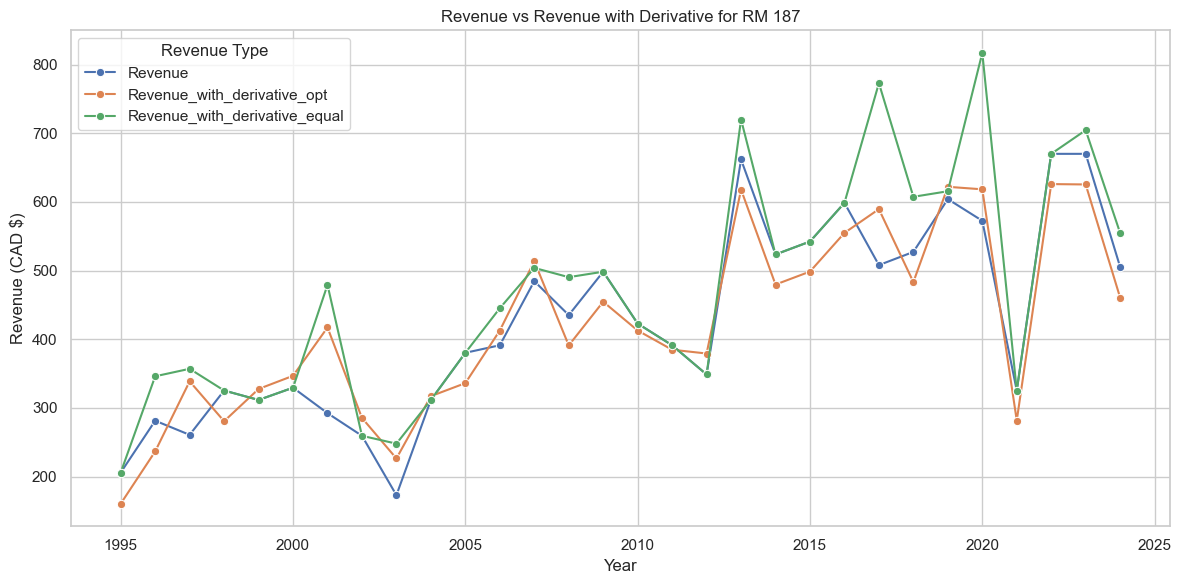

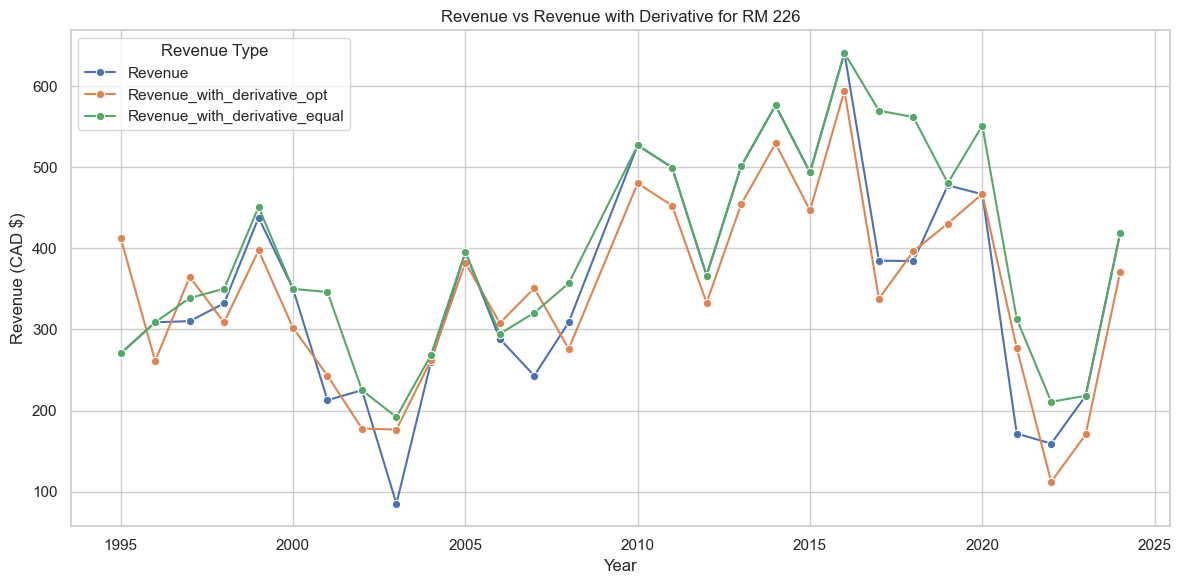

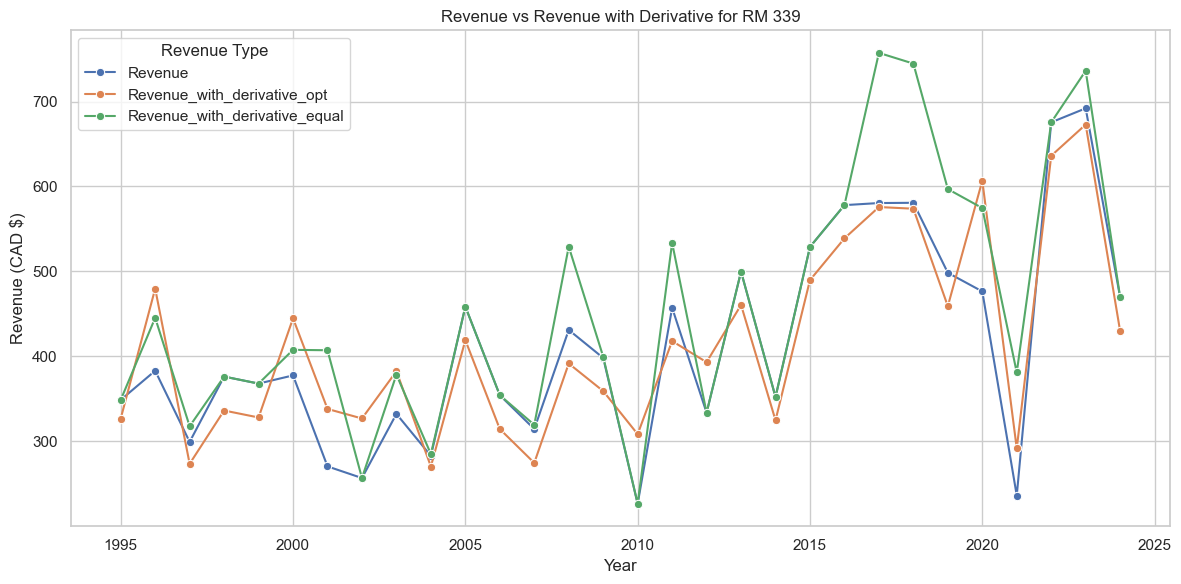

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---- Identify revenue columns automatically ----
revenue_cols = [c for c in df_clean.columns if c.startswith("Revenue")]
print("Revenue columns detected for plotting:", revenue_cols)

# ---- Prepare data for plotting ----
plot_df = df_clean.melt(
    id_vars=["LOCAL_YEAR", "RMs"],
    value_vars=revenue_cols,
    var_name="Revenue_Type",
    value_name="Revenue_Value"
)

# ---- Plot per RM ----
sns.set(style="whitegrid")
RMs = df_clean["RMs"].unique()

for rm in RMs:
    plt.figure(figsize=(12, 6))
    rm_data = plot_df[plot_df["RMs"] == rm]
    sns.lineplot(
        data=rm_data,
        x="LOCAL_YEAR",
        y="Revenue_Value",
        hue="Revenue_Type",
        marker="o"
    )
    plt.title(f"Revenue vs Revenue with Derivative for RM {rm}")
    plt.xlabel("Year")
    plt.ylabel("Revenue (CAD $)")
    plt.legend(title="Revenue Type")
    plt.tight_layout()
    plt.show()


In [30]:
# which measures captures downward trends. We are trying to avoid "negative" revenue compared to mean.
# ave revenue over 30 years baseline check instances when revenue without derivative below that baseline.
#   

In [162]:
def bootstrap_premium(F_index, theta, K, n_sim=10000, seed=42):
    """
    Compute rainfall derivative fair premium using empirical bootstrap simulation.
    """
    import numpy as np
    rng = np.random.default_rng(seed)

    # Convert to arrays
    F_index = np.array(F_index, dtype=float)
    n_years = len(F_index)

    # theta can be scalar or array-like
    if np.isscalar(theta):
        theta = np.full(n_years, theta)
    else:
        theta = np.array(theta, dtype=float)

    # K can be scalar or array-like
    if np.isscalar(K):
        K = np.full(n_years, K)
    else:
        K = np.array(K, dtype=float)

    # Bootstrap: resample historical years with replacement
    idx = rng.integers(0, n_years, size=(n_sim, n_years))

    # Simulated rainfall values
    sim_F = F_index[idx]  # shape: (n_sim, n_years)

    # Compute payoffs per simulation
    sim_payoff = np.where(sim_F < K, theta * (K - sim_F) / K, 0)

    # Fair premium = mean of simulated payoffs
    premium = sim_payoff.mean()

    return premium


In [163]:
# ---- Compute Bootstrap premiums per RM using df_clean ----
premiums = {}

for rm in df_clean["RMs"].unique():
    df_rm = df_clean[df_clean["RMs"] == rm]

    # Optimized rainfall index and strike (scalar per RM)
    F_index = df_rm["Rainfall_Index_opt"].values
    theta = df_rm["theta"].values
    K = df_rm["K_opt"].values[0]

    # Compute premium using bootstrap (instead of normal MC)
    premium = bootstrap_premium(F_index, theta, K, n_sim=10000)
    premiums[rm] = premium

# ---- Display bootstrap premiums ----
print("Estimated option premiums per RM using empirical bootstrap (CAD $):")
for rm, pr in premiums.items():
    print(f"RM {rm}: {pr:,.2f}")


Estimated option premiums per RM using empirical bootstrap (CAD $):
RM 187: 66.87
RM 226: 64.60
RM 339: 64.28


In [164]:
# ---- Net revenue after subtracting Bootstrap premium (optimized indemnity) ----
df_clean["Revenue_with_derivative_opt"] = (
    df_clean["Revenue"]
    + df_clean["Indemnity_opt"]
    - df_clean["RMs"].map(premiums)   # <= now uses bootstrap premiums
)


In [165]:
# ---- Hedge summary per RM using CLEAN dataset ----
hedge_summary = (
    df_clean.groupby("RMs")
        .agg(
            Revenue_SD=("Revenue", "std"),
            Revenue_with_derivative_SD=("Revenue_with_derivative_opt", "std")
        )
        .reset_index()
        .sort_values("RMs")
)

# ---- Compute hedge effectiveness (risk reduction) ----
hedge_summary["Hedge_Effectiveness"] = 1 - (
    hedge_summary["Revenue_with_derivative_SD"] /
    hedge_summary["Revenue_SD"].replace(0, np.nan)   # avoid division by 0
)

# ---- Convert to percentage ----
hedge_summary["Hedge_Effectiveness_pct"] = (
    hedge_summary["Hedge_Effectiveness"] * 100
)

print("\nHedge effectiveness using bootstrap-priced derivative:\n")
print(hedge_summary.to_string(index=False))



Hedge effectiveness using bootstrap-priced derivative:

 RMs  Revenue_SD  Revenue_with_derivative_SD  Hedge_Effectiveness  Hedge_Effectiveness_pct
 187  142.034274                  181.120415            -0.275188               -27.518810
 226  134.272147                  129.765448             0.033564                 3.356392
 339  124.589770                  155.640407            -0.249223               -24.922300


Revenue columns detected for plotting: ['Revenue', 'Revenue_with_derivative_opt', 'Revenue_with_derivative_equal']


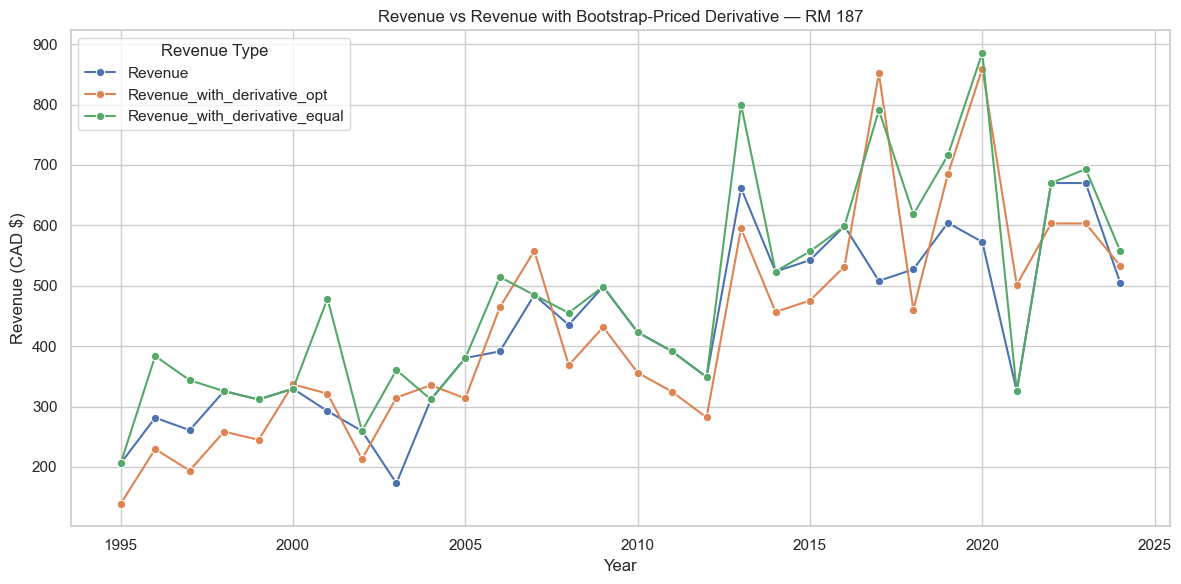

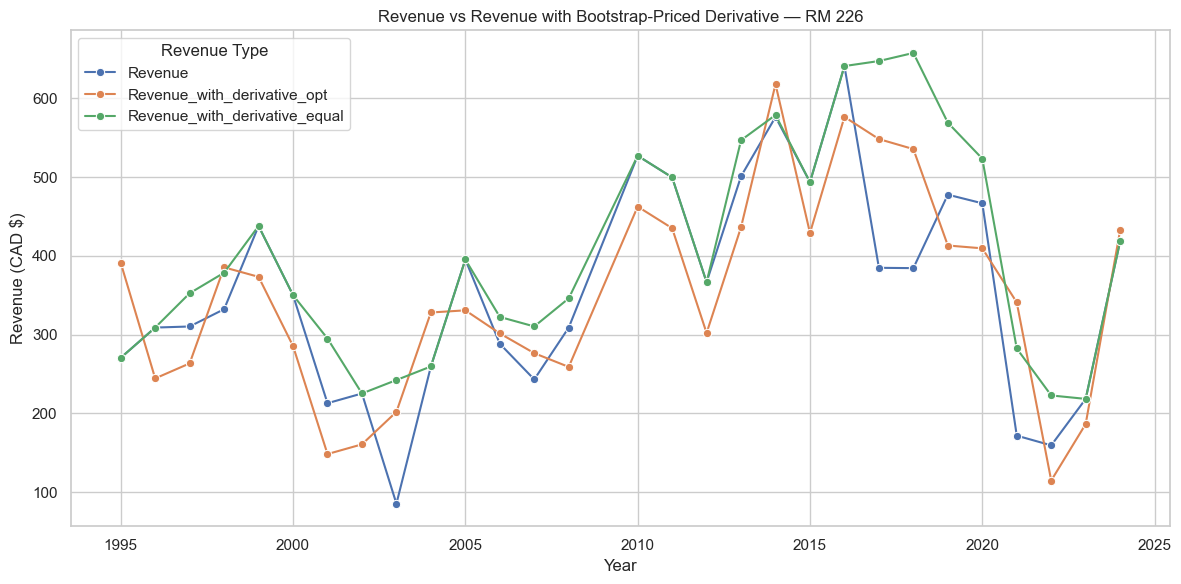

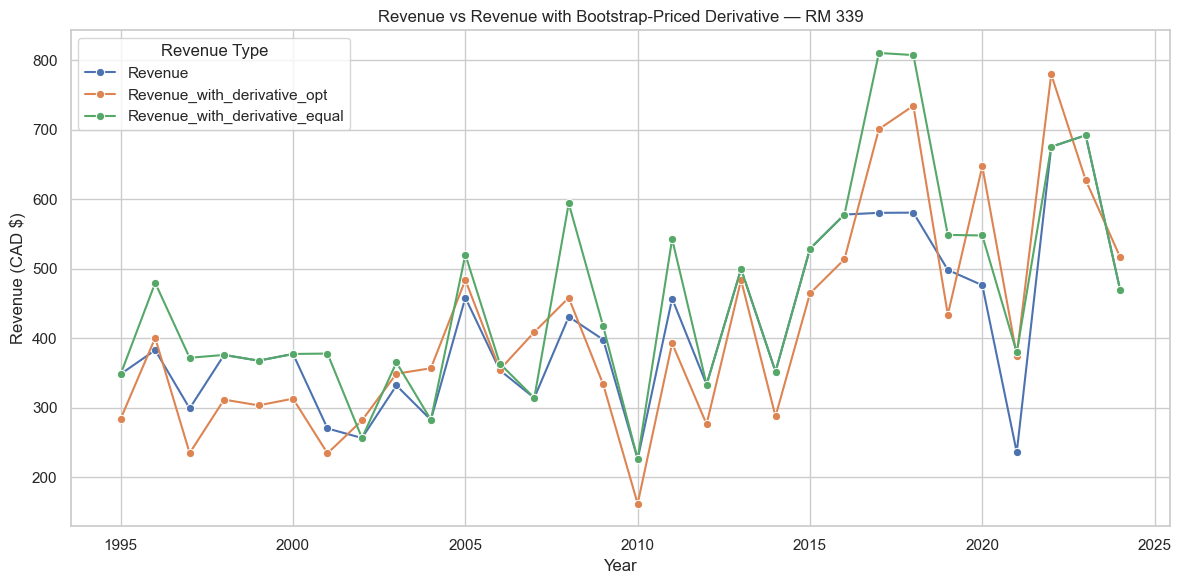

In [166]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---- Identify revenue columns (Revenue baseline + bootstrap-based derivative) ----
revenue_cols = [
    c for c in df_clean.columns
    if c.startswith("Revenue") and not c.endswith("_eq")  # ignore any old equal-weight versions
]

print("Revenue columns detected for plotting:", revenue_cols)

# ---- Prepare data for plotting ----
plot_df = df_clean.melt(
    id_vars=["LOCAL_YEAR", "RMs"],
    value_vars=revenue_cols,
    var_name="Revenue_Type",
    value_name="Revenue_Value"
)

# Ensure years sorted
plot_df = plot_df.sort_values(["RMs", "LOCAL_YEAR"])

# ---- Plot per RM ----
sns.set(style="whitegrid")
RMs = sorted(df_clean["RMs"].unique())

for rm in RMs:
    plt.figure(figsize=(12, 6))
    
    rm_data = plot_df[plot_df["RMs"] == rm]

    sns.lineplot(
        data=rm_data,
        x="LOCAL_YEAR",
        y="Revenue_Value",
        hue="Revenue_Type",
        marker="o"
    )

    plt.title(f"Revenue vs Revenue with Bootstrap-Priced Derivative — RM {rm}")
    plt.xlabel("Year")
    plt.ylabel("Revenue (CAD $)")

    # Format y-axis with commas
    plt.gca().get_yaxis().set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ','))
    )

    plt.legend(title="Revenue Type")
    plt.tight_layout()
    plt.show()


In [133]:
# LPM function
import numpy as np
import pandas as pd

def compute_lpm(series, mu, order):
    """
    Lower Partial Moment of given order.
    LPM(order) = mean( max(0, mu - R_t)^order )
    """
    shortfall = np.maximum(0, mu - series)
    return np.mean(shortfall**order)


In [134]:
results = []

for rm in sorted(df_clean["RMs"].unique()):
    
    df_rm = df_clean[df_clean["RMs"] == rm]
    
    # Revenue arrays
    R = df_rm["Revenue"].values
    R_hedged = df_rm["Revenue_with_derivative_opt"].values
    
    # Baseline target = mean revenue for that RM
    mu = R.mean()
    
    # ----- LPMs -----
    L0  = compute_lpm(R,         mu, 0)
    L1  = compute_lpm(R,         mu, 1)
    L2  = compute_lpm(R,         mu, 2)
    
    L0h = compute_lpm(R_hedged,  mu, 0)
    L1h = compute_lpm(R_hedged,  mu, 1)
    L2h = compute_lpm(R_hedged,  mu, 2)
    
    # ----- improvements -----
    imp0 = 1 - L0h/L0 if L0 > 0 else np.nan
    imp1 = 1 - L1h/L1 if L1 > 0 else np.nan
    imp2 = 1 - L2h/L2 if L2 > 0 else np.nan
    
    results.append([
        rm, mu,
        L0, L0h, imp0,
        L1, L1h, imp1,
        L2, L2h, imp2
    ])

lpm_df = pd.DataFrame(results, columns=[
    "RM", "Mu",
    "LPM0_base", "LPM0_hedged", "LPM0_improvement",
    "LPM1_base", "LPM1_hedged", "LPM1_improvement",
    "LPM2_base", "LPM2_hedged", "LPM2_improvement"
])

print(lpm_df)


    RM          Mu  LPM0_base  LPM0_hedged  LPM0_improvement  LPM1_base  \
0  187  427.108263        1.0          1.0               0.0  60.742740   
1  226  355.739566        1.0          1.0               0.0  54.893879   
2  339  414.577350        1.0          1.0               0.0  51.242648   

   LPM1_hedged  LPM1_improvement    LPM2_base  LPM2_hedged  LPM2_improvement  
0    63.880788         -0.051661  9211.080500  9750.533222         -0.058566  
1    52.088348          0.051108  8376.067163  7341.259461          0.123543  
2    53.581279         -0.045638  6166.963411  7944.194054         -0.288186  


LPM focuses only on bad outcomes (years below the mean).
So this measures risk where farmers actually care: losses, not swings on the upside.

LPM1 = average size of losses
LPM2 = penalizes large losses even more
LPM0 was 1 for both → no difference there (ignore it)

LPM1 and LPM2 Interpretation (downside risk)
| RM      | LPM1 (avg losses)                   | Interpretation                | LPM2 (big losses)      | Interpretation                      |
| ------- | ----------------------------------- | ----------------------------- | ------------------------ | ----------------------------------- |
| **187** | Losses got **slightly worse** (-5%) | Hedge increases downside risk | LPM2 worse (-6%)         | Big losses get slightly larger      |
| **226** | Losses got **better** (+5%)         | Hedge reduces downside risk   | LPM2 better (+12.9%)     | Big losses shrink noticeably        |
| **339** | Losses got **worse** (-4.5%)        | Hedge increases downside risk | LPM2 much worse (-29%)   | Big losses get significantly larger |


RM 226:
✔ Hedge helps.
✔ Lower volatility and lower downside losses.
→ Good hedge performance.

RM 187 & RM 339:
✘ Hedge hurts.
✘ More volatility, and worse downside risk.
→ Hedge is counter-productive for these regions.

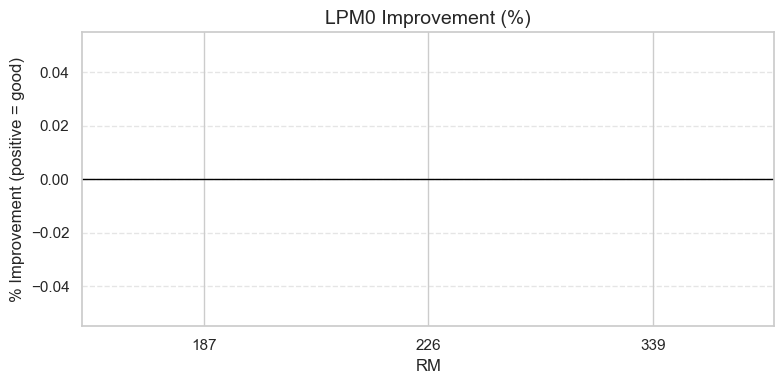

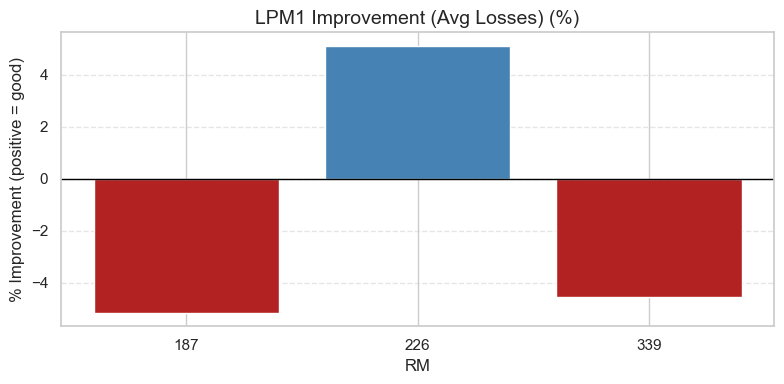

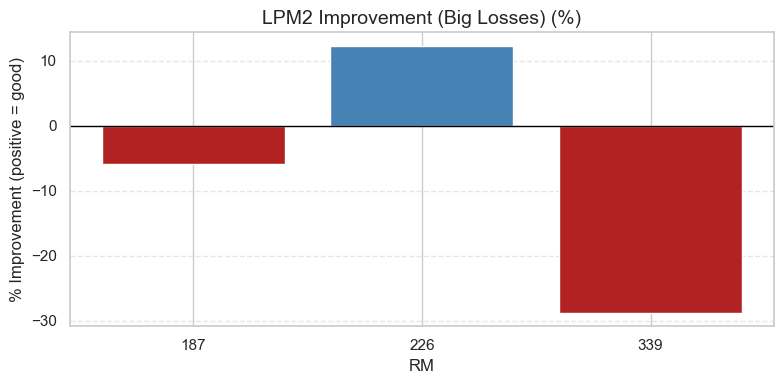

In [135]:
import matplotlib.pyplot as plt

metrics = [
    ("LPM0_improvement", "LPM0 Improvement (%)"),
    ("LPM1_improvement", "LPM1 Improvement (Avg Losses) (%)"),
    ("LPM2_improvement", "LPM2 Improvement (Big Losses) (%)")
]

for metric, title in metrics:
    
    plt.figure(figsize=(8,4))
    
    # Bar plot
    plt.bar(
        lpm_df["RM"].astype(str),
        lpm_df[metric] * 100,
        color=["steelblue" if v > 0 else "firebrick" for v in lpm_df[metric]]
    )
    
    # Labels & title
    plt.title(title, fontsize=14)
    plt.ylabel("% Improvement (positive = good)", fontsize=12)
    plt.xlabel("RM", fontsize=12)
    
    # Zero line
    plt.axhline(0, color="black", linewidth=1)
    
    # Grid
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()
